#### Setup and Load Cleaned Dataset

In [59]:
#pip install numpy pandas pathlib pyarrow fastparquet requests scikit-learn matplotlib
#pip install torch --index-url https://download.pytorch.org/whl/cu126
import numpy as np
import pandas as pd
from pathlib import Path
import requests
import sklearn
import matplotlib
#import pyarrow
#import fastparquet

#### Downloading External Data Sources
The taxi zone lookup dataset is downloaded and stored locally. This lookup table contains geographic information that is later used to map pickup and dropoff location IDs to borough names, enriching the dataset with spatial context.

In [60]:
# Create data directory and download the taxi zone lookup dataset if it is not already available locally
raw_path = Path("data/raw")
raw_path.mkdir(parents=True, exist_ok=True)

def download_file(url, save_path):
    if not save_path.exists():  # download file only if it does not already exist
        print(f"Downloading {save_path.name}...")
        response = requests.get(url)
        response.raise_for_status()
        with open(save_path, "wb") as f:
            f.write(response.content)
        print("Download complete.")
    else:
        print(f"{save_path.name} already exists.")  # skip download if file already exists


# Download zone lookup file
zone_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

zone_path = raw_path / "taxi_zone_lookup.csv"
download_file(zone_url, zone_path)  # download lookup table

zones = pd.read_csv(zone_path)  # load zone lookup dataset into a dataframe

taxi_zone_lookup.csv already exists.


### Loads cleaned dataset.
change path as needed

In [61]:
#change this path to your cleaned data file
CLEAN_PATH = Path("data/processed/cleaned_taxi_2024_01.parquet")

df = pd.read_parquet(CLEAN_PATH, engine="pyarrow")
print("Loaded With Shape:", df.shape)
df.head()

Loaded With Shape: (2869572, 26)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,trip_duration_minutes,trip_speed_mph,pickup_hour,pickup_day_of_week,LocationID,pickup_zone,pickup_date
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,...,22.70,2.5,0.0,19.800000,5.212121,0,Monday,186,Penn Station/Madison Sq West,2024-01-01
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,...,18.75,2.5,0.0,6.600000,16.363636,0,Monday,140,Lenox Hill East,2024-01-01
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,...,31.30,2.5,0.0,17.916667,15.739535,0,Monday,236,Upper East Side North,2024-01-01
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,...,17.00,2.5,0.0,8.300000,10.120482,0,Monday,79,East Village,2024-01-01
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,...,16.10,2.5,0.0,6.100000,7.868852,0,Monday,211,SoHo,2024-01-01


#### Dataset Schema Validation
Before proceeding with feature engineering and modeling, a schema check is performed to ensure that all required columns are present in the cleaned dataset. This helps detect missing or incorrectly loaded fields early in the pipeline.

In [62]:
# Verify that the cleaned dataset contains all required columns for modeling
required_cols = {
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "trip_distance", "fare_amount", "tip_amount",
    "payment_type", "PULocationID", "DOLocationID",
    "passenger_count", "total_amount"
}

missing = required_cols - set(df.columns)  # identify any required columns that are missing
if missing:
    raise ValueError(f"Cleaned dataset missing required columns: {missing}")  # raise error if schema is incomplete

print("Schema check passed :3")  # confirm dataset contains all required fields

Schema check passed :3


#### Filter for Credit card payments only

To ensure consistent tipping data, the dataset is filtered to include only trips paid by credit card. Credit card transactions reliably record tip amounts, whereas cash payments often do not include recorded tips.

In [63]:
# Filter dataset to include only credit card payments where tip amounts are reliably recorded
df = df[df["payment_type"] == 1].copy()

print("Shape after CC filter:", df.shape)  # display dataset size after filtering

Shape after CC filter: (2298347, 26)


## Part 1: Data Preprocessing & Feature Engineering

#### Feature engineering

Several engineered features are created to capture temporal patterns, trip characteristics, and fare-related behavior. These features include pickup time indicators, trip duration and speed, and normalized fare metrics. Feature engineering helps the models better capture relationships that may influence tipping behavior.

In [64]:
#creates features for modeling
# Ensure datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Temporal features
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
df["pickup_day_of_week"] = df["tpep_pickup_datetime"].dt.dayofweek

# Weekend indicator (5=Saturday, 6=Sunday)
df["is_weekend"] = df["pickup_day_of_week"].isin([5,6])

# Trip features
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60.0

# trip speed in mph
duration_hours = df["trip_duration_minutes"] / 60.0
df["trip_speed_mph"] = np.where(
    duration_hours > 0,
    df["trip_distance"] / duration_hours,
    np.nan
)

# Log trip distance
df["log_trip_distance"] = np.log1p(df["trip_distance"])

# Fare features
df["fare_per_mile"] = np.where(
    df["trip_distance"] > 0,
    df["fare_amount"] / df["trip_distance"],
    np.nan
)

df["fare_per_minute"] = np.where(
    df["trip_duration_minutes"] > 0,
    df["fare_amount"] / df["trip_duration_minutes"],
    np.nan
)

#### Targets

Two target variables are created for modeling. The regression target is the actual tip amount, while the classification target identifies whether a trip received a high tip (defined as a tip greater than 20% of the fare). The class distribution of the high-tip variable is also examined.

In [65]:
# Create regression and classification targets based on tip amount and tip percentage
df["tip_amount_target"] = df["tip_amount"]  # regression target: actual tip amount

tip_pct = np.where(
    df["fare_amount"] > 0,
    df["tip_amount"] / df["fare_amount"],  # compute tip percentage relative to fare
    0
)

df["high_tip"] = (tip_pct > 0.20).astype(int)  # classification target: 1 if tip exceeds 20% of fare

print(df["high_tip"].value_counts(normalize=True))  # display proportion of high-tip vs non-high-tip trips

high_tip
1    0.759326
0    0.240674
Name: proportion, dtype: float64


The target variable high_tip is moderately imbalanced, with roughly 75% of trips falling into the non–high-tip category and about 25% exceeding the 20% tipping threshold.
Because of this imbalance, evaluation metrics such as F1 score and ROC-AUC were emphasized during model selection and hyperparameter tuning, as they provide a more reliable measure of performance than accuracy alone when class distributions are uneven.

#### Feature Engineering Zones Features


##### Merging Borough Information from Zone Lookup

To enrich the dataset with geographic context, borough information is merged from the taxi zone lookup table using pickup and dropoff location IDs. After the merges, temporary join keys are removed to prevent duplicate or unnecessary columns.

In [66]:
# Prepare a smaller lookup table containing only the required zone information
zones_small = zones[["LocationID", "Borough"]].copy()

# Merge pickup borough information using pickup location ID
df = df.merge(
    zones_small,
    left_on="PULocationID",
    right_on="LocationID",
    how="left",
    suffixes=("", "_zonePU")
).rename(columns={"Borough": "PU_Borough"})

# Remove temporary join key columns created during the merge
for col in ["LocationID", "LocationID_zonePU"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Merge dropoff borough information using dropoff location ID
df = df.merge(
    zones_small,
    left_on="DOLocationID",
    right_on="LocationID",
    how="left",
    suffixes=("", "_zoneDO")
).rename(columns={"Borough": "DO_Borough"})

# Remove temporary join key columns created during the merge
for col in ["LocationID", "LocationID_zoneDO"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Check proportion of missing borough values after merge
print("Missing PU borough %:", df["PU_Borough"].isna().mean())
print("Missing DO borough %:", df["DO_Borough"].isna().mean())

# Verify remaining location-related columns
print([c for c in df.columns if "LocationID" in c])

Missing PU borough %: 0.00013487954603895756
Missing DO borough %: 0.003414192896024839
['PULocationID', 'DOLocationID']


#### Cleaning Merge Artifacts

After merging the taxi trip dataset with zone lookup tables, some intermediate merge key columns may remain in the dataframe. These columns are removed to avoid redundancy and ensure that only relevant modeling features remain.

In [67]:
# Remove leftover merge key columns created during earlier dataset joins
to_drop = [c for c in df.columns if c.startswith("LocationID_")]
if to_drop:
    df = df.drop(columns=to_drop)

# verify remaining location-related columns
print("Remaining LocationID-like columns:", [c for c in df.columns if "LocationID" in c])

Remaining LocationID-like columns: ['PULocationID', 'DOLocationID']


#### Selecting Features for Modeling Dataframe

The final modeling dataset includes engineered temporal, trip, and fare-related features, along with categorical location variables and core trip attributes. These features are selected based on their potential relevance for predicting both tip amount (regression) and high-tip behavior (classification). Invalid values such as infinities are removed and rows with missing values are dropped to ensure clean model input.

In [68]:
# Define the feature set and target variables used for modeling
model_cols = [
    # engineered temporal + trip + fare
    "pickup_hour", "pickup_day_of_week", "is_weekend",
    "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_per_mile", "fare_per_minute",

    # zone features (categorical)
    "PU_Borough", "DO_Borough",

    # extra numeric features allowed
    "passenger_count", "trip_distance", "fare_amount", "total_amount",

    # targets
    "tip_amount_target", "high_tip"
]

# Prepare the final modeling dataset by selecting relevant columns and removing invalid values
df_model = df[model_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
print("Final modeling shape:", df_model.shape) # display number of rows and columns in modeling dataset
print(df_model.dtypes) # display data types of each feature

Final modeling shape: (2290381, 16)
pickup_hour                int32
pickup_day_of_week         int32
is_weekend                  bool
trip_duration_minutes    float64
trip_speed_mph           float64
log_trip_distance        float64
fare_per_mile            float64
fare_per_minute          float64
PU_Borough                   str
DO_Borough                   str
passenger_count          float64
trip_distance            float64
fare_amount              float64
total_amount             float64
tip_amount_target        float64
high_tip                   int64
dtype: object


We retained ~2.29 million rows which indicates a strong dataset size.

#### Train–Validation–Test Split 70/15/15 (stratified on high_tip):

The dataset is divided into training, validation, and test sets. First, a 15% test set is separated to provide an unbiased final evaluation. The remaining data is then split into training and validation sets. Stratified sampling is used to preserve the class distribution of the high_tip target across all splits.

In [69]:
# Split dataset into training, validation, and test sets while preserving class distribution
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["tip_amount_target", "high_tip"])  # features used for modeling
y_reg = df_model["tip_amount_target"].values  # regression target (tip amount)
y_clf = df_model["high_tip"].values  # classification target (high tip indicator)

# First split: create held-out test set
X_trainval, X_test, y_reg_trainval, y_reg_test, y_clf_trainval, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.15, random_state=42, stratify=y_clf
)

# Second split: divide remaining data into training and validation sets
val_size = 0.15 / 0.85
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_trainval, y_reg_trainval, y_clf_trainval, test_size=val_size, random_state=42, stratify=y_clf_trainval
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)  # display dataset sizes

# Helper function to inspect class distribution in each split
def show_dist(name, y):
    s = pd.Series(y).value_counts(normalize=True).sort_index()  # compute normalized class proportions
    print(f"{name} high_tip distribution:", s.to_dict())  # display distribution as dictionary

show_dist("Train", y_clf_train)
show_dist("Val", y_clf_val)
show_dist("Test", y_clf_test)

Train: (1603266, 14) Val: (343557, 14) Test: (343558, 14)
Train high_tip distribution: {0: 0.23992026276363373, 1: 0.7600797372363662}
Val high_tip distribution: {0: 0.2399194311278769, 1: 0.7600805688721232}
Test high_tip distribution: {0: 0.23991873279038764, 1: 0.7600812672096123}


Train/Val/Test split corresponds to 70/15/15 ratio  
where each split shows a stratification of ~ 24%-76% split with respect to class 1 - class 0

#### Preprocessing pipeline (scale numeric on train only, one-hot boroughs)

To improve memory efficiency on this large dataset, the preprocessing pipeline was configured to preserve sparse matrix output,  preventing unnecessary densification during scaling and one-hot encoding.

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric feature list (scaled)
numeric_features = [
    "pickup_hour", "pickup_day_of_week",
    "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_per_mile", "fare_per_minute",
    "passenger_count", "trip_distance", "fare_amount", "total_amount",
    "is_weekend"  
]

# Categorical feature list (one-hot encoded)
categorical_features = ["PU_Borough", "DO_Borough"]

# Scale numeric features without centering to keep matrix sparse-friendly
numeric_transformer = StandardScaler(with_mean=False)

# One-hot encode boroughs and keep output sparse
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

# Combine numeric scaling + categorical encoding into one pipeline
# sparse_threshold=1.0 keeps output sparse to reduce memory usage
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Preprocessor ready (memory-efficient).")

Numeric features: ['pickup_hour', 'pickup_day_of_week', 'trip_duration_minutes', 'trip_speed_mph', 'log_trip_distance', 'fare_per_mile', 'fare_per_minute', 'passenger_count', 'trip_distance', 'fare_amount', 'total_amount', 'is_weekend']
Categorical features: ['PU_Borough', 'DO_Borough']
Preprocessor ready (memory-efficient).


Numerical and Categorical features verified.

## Part 2: Model Training & Tuning

#### Baseline Models

Because the training set is very large (~1.6M rows), the RandomForest models were constrained (shallower trees, fewer trees, and   subsampling per tree) to reduce runtime and memory usage on a my laptop (16GB Ram) while still providing a valid nonlinear   baseline for comparison.

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_recall_fscore_support, roc_auc_score
)

# Regression pipelines
#linear regression pipeline
linreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

#random forest regression pipeline
rfreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=30,        # fewer trees = much faster + less memory (baseline model)
        max_depth=14,           # cap tree depth to prevent overly large trees on 1.6M rows
        min_samples_leaf=30,    # force leaves to have enough samples (reduces overfitting + size)
        min_samples_split=60,   # require more samples to split (further limits tree growth)
        max_features="sqrt",    # standard RF default for stability/speed
        bootstrap=True,         # needed for max_samples to take effect
        max_samples=0.20,       # each tree trains on 20% of rows (major runtime/memory reduction)
        n_jobs=1,               # Windows stability: prevents memory duplication when using multiple processes
        random_state=42
    ))
])

# Classification pipelines
#logistic regression pipeline
logreg_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,          # allow more iterations so it converges on large data
        solver="lbfgs"          # stable default solver for binary classification
    ))
])

#random forest classification pipeline
rfclf_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=30,        # fewer trees = much faster + less memory (baseline model)
        max_depth=14,           # cap tree depth to prevent overly large trees
        min_samples_leaf=30,    # reduce overfitting + reduce tree size
        min_samples_split=60,   # reduce tree growth (faster + more stable)
        max_features="sqrt",    # common RF setting
        bootstrap=True,         # needed for max_samples to take effect
        max_samples=0.20,       # each tree uses 20% of training rows
        n_jobs=1,               # Windows stability: prevents memory duplication
        random_state=42
    ))
])

#### Training Baseline Models (fit models) with timing

To compare the computational cost of each model, a helper function is used to measure the time required to fit each pipeline on the training data. This provides insight into the relative training efficiency of linear models versus tree-based models.

In [72]:
# Define a helper function to measure and display training time for each model pipeline
import time

def timed_fit(name, pipe, X, y):
    t0 = time.time()  # record start time before model training
    pipe.fit(X, y)  # train the model pipeline on the provided data
    print(f"{name} fit time: {time.time() - t0:.1f}s")  # print elapsed training time

# Train models and report training time for each
timed_fit("LinearRegression", linreg_pipe, X_train, y_reg_train)
timed_fit("LogisticRegression", logreg_pipe, X_train, y_clf_train)
timed_fit("RF Regressor", rfreg_pipe, X_train, y_reg_train)
timed_fit("RF Classifier", rfclf_pipe, X_train, y_clf_train)

LinearRegression fit time: 5.8s
LogisticRegression fit time: 17.6s
RF Regressor fit time: 186.6s
RF Classifier fit time: 171.7s


#### Validation evaluation funtions:

The following functions evaluate model performance on the validation dataset. Separate evaluation functions are defined for regression and classification tasks, computing standard metrics such as MAE, RMSE, and R² for regression, and Accuracy, Precision, Recall, F1-score, and ROC-AUC for classification. These results allow comparison of baseline models before hyperparameter tuning and final testing.

In [73]:
# Import evaluation metrics and define helper functions to assess regression and classification models on the validation set
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# Define evaluation function for regression models
def eval_reg(pipe, Xv, yv):
    pred = pipe.predict(Xv)  # generate predictions from regression model
    return {
        "MAE": mean_absolute_error(yv, pred),  # compute mean absolute error
        "RMSE": np.sqrt(mean_squared_error(yv, pred)),  # compute root mean squared error
        "R2": r2_score(yv, pred)  # compute coefficient of determination
    }

# Define evaluation function for classification models
def eval_clf(pipe, Xv, yv):
    pred = pipe.predict(Xv)  # generate predicted class labels
    proba = pipe.predict_proba(Xv)[:, 1]  # obtain predicted probabilities for positive class
    return {
        "Accuracy": accuracy_score(yv, pred),  # compute classification accuracy
        "Precision": precision_score(yv, pred, zero_division=0),  # compute precision
        "Recall": recall_score(yv, pred, zero_division=0),  # compute recall
        "F1": f1_score(yv, pred, zero_division=0),  # compute F1-score
        "ROC_AUC": roc_auc_score(yv, proba)  # compute area under ROC curve
    }

# Create validation comparison tables for regression and classification models
reg_table = pd.DataFrame({
    "LinearRegression": eval_reg(linreg_pipe, X_val, y_reg_val),
    "RFRegressor": eval_reg(rfreg_pipe, X_val, y_reg_val)
}).T

clf_table = pd.DataFrame({
    "LogisticRegression": eval_clf(logreg_pipe, X_val, y_clf_val),
    "RFClassifier": eval_clf(rfclf_pipe, X_val, y_clf_val)
}).T

print("Regression (Validation):")  # print regression validation results
display(reg_table)

print("Classification (Validation):")  # print classification validation results
display(clf_table)

Regression (Validation):


,MAE,RMSE,R2
LinearRegression,0.841616,1.378844,0.859323
RFRegressor,0.676443,1.422530,0.850267


Classification (Validation):


,Accuracy,Precision,Recall,F1,ROC_AUC
LogisticRegression,0.873232,0.870222,0.979256,0.921525,0.882126
RFClassifier,0.869247,0.859224,0.990212,0.920079,0.951404


### Validation Results and Baseline Comparison

For the regression task, both Linear Regression and the Random Forest Regressor performed strongly on the validation set. Linear Regression achieved a slightly higher R² (0.859) and lower RMSE, while the Random Forest achieved a lower MAE. The differences between the models are relatively small, indicating that the engineered features already explain most of the variability in tip amount using a linear relationship. The additional nonlinear flexibility of the Random Forest does not produce a substantial improvement under the current configuration. 

This suggests that the regression problem is largely linear in nature, and that the simpler model is already capturing the dominant signal in the data.

For the classification task, both models achieved high overall performance. Logistic Regression produced slightly higher accuracy and F1 score, while the Random Forest achieved a substantially higher ROC-AUC (0.951 vs 0.882). The improvement in ROC-AUC indicates that the Random Forest provides better probability separation between high-tip and non-high-tip trips across thresholds, even though overall accuracy remains similar.

The consistently high recall for both models indicates that the engineered features are strong predictors of high tipping behavior. However, the Random Forest’s higher ROC-AUC suggests that nonlinear feature interactions contribute meaningfully to classification performance.

Overall, the baseline results demonstrate that the regression task is largely linear, while the classification task benefits more from nonlinear modeling. These results establish a clear reference point prior to hyperparameter tuning, where the objective will be to determine whether further improvements can be achieved without excessive computational cost.

### Hyperparametric Tuning

Given the large size of the training dataset (~1.6M rows), hyperparameter tuning was performed on a stratified random sample of 300,000 rows to reduce computational cost while maintaining representativeness of the full training dataset.

A randomized search with cross-validation was used to explore key Random Forest hyperparameters controlling tree complexity and sampling behaviour. The objective was to determine whether improved validation performance could be achieved beyond the constrained baseline configuration.

The tuned model is evaluated on the full validation set after selection. The test set remains untouched at this stage to avoid data leakage.

In [74]:
# Import hyperparameter tuning utility and create a random subset of the training data for efficient tuning
from sklearn.model_selection import RandomizedSearchCV

# Use 300k rows for tuning 
N_TUNE = 300000

rng = np.random.RandomState(42)  # initialize random generator for reproducibility
indices = rng.choice(len(X_train), size=N_TUNE, replace=False)  # randomly sample indices from training data

X_tune = X_train.iloc[indices]  # select sampled feature rows for tuning
y_clf_tune = y_clf_train[indices]  # select corresponding sampled labels

print("Tuning subset shape:", X_tune.shape)  # display size of tuning subset

Tuning subset shape: (300000, 14)


#### Define Parameter Grid 

Hyperparameter Search Space  
The following parameter grid defines the range of hyperparameters explored during randomized search for the Random Forest classifier. These parameters control tree depth, sampling behavior, and feature selection, allowing the model to balance complexity, generalization, and computational efficiency.

In [75]:
# Define the hyperparameter search space for Random Forest tuning
param_dist = {
    "model__n_estimators": [30, 50, 70],  # number of trees in the forest
    "model__max_depth": [12, 16, 20],  # maximum depth of each decision tree
    "model__min_samples_leaf": [10, 20, 40],  # minimum samples required at leaf nodes
    "model__max_samples": [0.10, 0.20, 0.30],  # fraction of training data used for each tree
    "model__max_features": ["sqrt", 0.5]  # number of features considered when splitting nodes
}

Run Randomized Search (Classification First)

RandomizedSearchCV is used to tune the hyperparameters of the Random Forest classifier. The search evaluates multiple parameter combinations using 5-fold cross-validation and selects the model that achieves the best F1-score, which is appropriate for the moderately imbalanced classification problem.

In [76]:
# Perform randomized hyperparameter search for the Random Forest classifier using 5-fold cross-validation
rf_tune = RandomizedSearchCV(
    rfclf_pipe,
    param_distributions=param_dist,
    n_iter=20,                # number of random parameter combinations to evaluate
    scoring="f1",             # optimize model selection based on F1-score
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=1                 
)

rf_tune.fit(X_tune, y_clf_tune)  # run hyperparameter search on the tuning subset

print("Best parameters:", rf_tune.best_params_)  # display best hyperparameter configuration
print("Best CV F1:", rf_tune.best_score_)  # display best cross-validation F1 score

best_rfclf = rf_tune.best_estimator_  # retrieve the tuned Random Forest model

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'model__n_estimators': 70, 'model__min_samples_leaf': 20, 'model__max_samples': 0.3, 'model__max_features': 0.5, 'model__max_depth': 20}
Best CV F1: 0.9629158222326435


#### Hyperparameter Tuning Results (Random Forest Classifier)

A randomized search with 5 fold cross-validation was conducted over 20 parameter combinations (100 total model fits) using a sampled subset of the training data. 

The best-performing configuration was:

- n_estimators = 70  
- max_depth = 20  
- min_samples_leaf = 20  
- max_samples = 0.3  
- max_features = 0.5  

The best cross-validated F1 score achieved during tuning was **0.963**.

The selected parameters indicate that the model benefits from increased tree depth and a larger number of trees compared to the constrained baseline, while still maintaining regularization through minimum leaf size and subsampling. This suggests that additional nonlinear complexity improves classification performance without excessive overfitting.

#### Random Forest Validation Performance (Baseline vs Tuned) Code

After hyperparameter tuning, the best Random Forest model from the randomized search is selected and evaluated on the validation set. The validation performance of the tuned model is then compared with the baseline Random Forest to determine whether hyperparameter tuning improved predictive performance.

In [77]:
# Select the best tuned Random Forest model and compare its validation performance against the baseline model
best_rfclf = rf_tune.best_estimator_

tuned_val = eval_clf(best_rfclf, X_val, y_clf_val)
baseline_val = eval_clf(rfclf_pipe, X_val, y_clf_val)

print("Baseline RF (Validation):", baseline_val)
print("Tuned RF (Validation):", tuned_val)

Baseline RF (Validation): {'Accuracy': 0.8692473155837314, 'Precision': 0.8592244301189605, 'Recall': 0.990211809398348, 'F1': 0.920079491736809, 'ROC_AUC': 0.9514039067800997}
Tuned RF (Validation): {'Accuracy': 0.9452259741469392, 'Precision': 0.9443452173562236, 'Recall': 0.9860491477457675, 'F1': 0.9647467000378424, 'ROC_AUC': 0.9876903021351399}


#### Validation Performance: Baseline vs Tuned Model

The tuned Random Forest model was evaluated on the full validation set and compared to the constrained baseline.

**Baseline RF (Validation):**
- Accuracy: 0.869  
- Precision: 0.859  
- Recall: 0.990  
- F1: 0.920  
- ROC-AUC: 0.951  

**Tuned RF (Validation):**
- Accuracy: 0.945  
- Precision: 0.944  
- Recall: 0.986  
- F1: 0.965  
- ROC-AUC: 0.988  

The tuned model demonstrates a substantial improvement across all key metrics. Accuracy increased by over 7 percentage points, and F1 improved from 0.920 to 0.965. The ROC-AUC also increased notably, indicating significantly better probability separation between high-tip and non-high-tip trips.

While recall remains high in both models, the tuned model greatly improves precision, meaning it reduces false positives while still correctly identifying high-tip trips. This indicates that allowing greater model complexity (deeper trees and more trees) enabled the model to capture more informative nonlinear feature interactions.

Overall, hyperparameter tuning produced a meaningful and consistent improvement in validation performance, justifying selection of the tuned Random Forest classifier for final evaluation on the test set.

### Neural Network Model

A feedforward neural network was trained for the classification task (predicting 'high_tip'). This follows the Lab 4 workflow (Dataset/DataLoader, training loop, validation monitoring, and loss curves). The model uses BCEWithLogitsLoss and is trained for at least 20 epochs, as required.  

The neural network was trained on the full training split to avoid sampling bias and to provide a direct comparison against the best-performing scikit-learn classifiers. Validation loss was monitored across epochs to verify training stability and check for overfitting.

In [78]:
# Import PyTorch modules for neural network modeling, dataset handling, plotting, and evaluation metrics
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

#### Preparing Data for Neural Network Training

The neural network uses the full training split of the dataset. The preprocessing pipeline is fitted only on the training data to avoid data leakage, and then applied to both the training and validation sets. The transformed feature matrices are converted to dense float32 arrays so they can be used as PyTorch tensors during neural network training.

In [79]:
# Use the full training split for NN training
X_train_nn_raw = X_train 
# convert training labels to float32 for PyTorch compatibility
y_train_nn = y_clf_train.astype(np.float32)  

# Fit preprocessor on training split (only on training data, not validation or test)
preprocessor_nn = preprocessor 
preprocessor_nn.fit(X_train) 

# Transform: train sample + full validation
X_train_nn = preprocessor_nn.transform(X_train_nn_raw) 
X_val_nn = preprocessor_nn.transform(X_val) 

# Convert to dense float32 (NN expects dense tensors)
X_train_nn = X_train_nn.toarray().astype(np.float32) if hasattr(X_train_nn, "toarray") else X_train_nn.astype(np.float32)  # convert training features
X_val_nn = X_val_nn.toarray().astype(np.float32) if hasattr(X_val_nn, "toarray") else X_val_nn.astype(np.float32)  # convert validation features

# convert validation labels to float32 for neural network
y_val_nn = y_clf_val.astype(np.float32)  

print("NN train X:", X_train_nn.shape, "y:", y_train_nn.shape)  # print training dataset dimensions
print("NN val   X:", X_val_nn.shape, "y:", y_val_nn.shape)  # print validation dataset dimensions

NN train X: (1603266, 26) y: (1603266,)
NN val   X: (343557, 26) y: (343557,)


#### PyTorch Dataset and DataLoader Preparation

To efficiently train the neural network, the tabular data is wrapped in a custom PyTorch Dataset class. This allows the data to be loaded in mini-batches using DataLoader, which improves training efficiency and enables batch-based gradient updates.

In [80]:
# custom dataset class for tabular data
class TabularDataset(Dataset):  
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)  # convert feature matrix from NumPy array to PyTorch tensor
        self.y = torch.from_numpy(y)  # convert target labels from NumPy array to PyTorch tensor

    def __len__(self):
        return len(self.y)  # return total number of samples in the dataset

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]  # return a single feature-target pair by index

# large batch size improves efficiency for tabular CPU training, can also use 4096
batch_size = 8192  

# create dataset object for training data
train_ds = TabularDataset(X_train_nn, y_train_nn)
# create dataset object for validation data  
val_ds = TabularDataset(X_val_nn, y_val_nn)  

# create DataLoader for training batches
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
# create DataLoader for validation batches  
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)  

The neural network is implemented as a feedforward binary classifier with two hidden layers. Each hidden layer uses ReLU activation and dropout regularization to improve generalization and reduce overfitting. The final layer outputs a single logit value representing the predicted probability of a high-tip trip.

In [81]:
class BinaryClassifier(nn.Module):  # define a feedforward neural network for binary classification
    def __init__(self, input_size, hidden_sizes=(128, 64), dropout=0.2):
        super().__init__()  # initialize base PyTorch module
        self.net = nn.Sequential(  # define sequential stack of layers

            nn.Linear(input_size, hidden_sizes[0]),  # first fully connected layer
            nn.ReLU(),  # apply ReLU activation
            nn.Dropout(dropout),  # apply dropout regularization

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),  # second fully connected layer
            nn.ReLU(),  # apply ReLU activation
            nn.Dropout(dropout),  # apply dropout regularization

            nn.Linear(hidden_sizes[1], 1)  # output layer producing a single logit value
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # forward pass returning logits with shape (batch,)

The neural network model is initialized and configured for training. The computation device (GPU via CUDA if available, otherwise CPU) is selected, the model architecture is defined, and the loss function and optimizer are specified for training.

In [82]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # select GPU if available, otherwise use CPU
print("Device:", device)  # display which device will be used for training

input_size = X_train_nn.shape[1]  # determine number of input features for the neural network
model = BinaryClassifier(input_size=input_size, hidden_sizes=(128, 64), dropout=0.2).to(device)  # initialize model and move it to selected device

criterion = nn.BCEWithLogitsLoss()  # define binary cross-entropy loss with logits for binary classification
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # initialize Adam optimizer to update model parameters during training

Device: cuda


#### Neural Network Training Loop
The neural network is trained for 20 epochs using mini-batch gradient descent with the Adam optimizer and binary cross-entropy loss. After each epoch, the model is evaluated on the validation set to track validation loss and accuracy, allowing monitoring of convergence and generalization performance over time.

In [83]:
def evaluate_epoch(model, loader, criterion, device):
    model.eval()  # set model to evaluation mode
    total_loss = 0.0  # accumulate total validation loss
    all_probs = []  # store predicted probabilities for all validation batches
    all_true = []  # store true labels for all validation batches

    with torch.no_grad():  # disable gradient computation during validation
        for Xb, yb in loader:
            Xb = Xb.to(device)  # move validation features to device
            yb = yb.to(device)  # move validation labels to device

            logits = model(Xb)  # compute model outputs for the batch
            loss = criterion(logits, yb)  # compute batch validation loss
            total_loss += loss.item() * len(yb)  # add weighted batch loss to total

            probs = torch.sigmoid(logits).detach().cpu().numpy()  # convert logits to probabilities
            all_probs.append(probs)  # store batch probabilities
            all_true.append(yb.detach().cpu().numpy())  # store batch true labels

    avg_loss = total_loss / len(loader.dataset)  # compute average validation loss across all samples
    all_probs = np.concatenate(all_probs)  # combine all batch probabilities into one array
    all_true = np.concatenate(all_true)  # combine all batch labels into one array

    preds = (all_probs >= 0.5).astype(int)  # convert probabilities to binary predictions

    acc = accuracy_score(all_true, preds)  # compute validation accuracy
    return avg_loss, acc  # return average validation loss and accuracy

EPOCHS = 20  # set number of training epochs to the required minimum

train_losses = []  # store training loss after each epoch
val_losses = []  # store validation loss after each epoch
val_accs = []  # store validation accuracy after each epoch

for epoch in range(1, EPOCHS + 1):
    model.train()  # set model to training mode
    running_loss = 0.0  # accumulate total training loss for the epoch

    for Xb, yb in train_loader:
        Xb = Xb.to(device)  # move training features to device
        yb = yb.to(device)  # move training labels to device

        optimizer.zero_grad()  # clear previous gradients
        logits = model(Xb)  # compute model outputs for the batch
        loss = criterion(logits, yb)  # compute batch training loss
        loss.backward()  # backpropagate gradients
        optimizer.step()  # update model parameters

        running_loss += loss.item() * len(yb)  # add weighted batch loss to total

    train_loss = running_loss / len(train_loader.dataset)  # compute average training loss for the epoch
    val_loss, val_acc = evaluate_epoch(model, val_loader, criterion, device)  # evaluate model on validation set

    train_losses.append(train_loss)  # store epoch training loss
    val_losses.append(val_loss)  # store epoch validation loss
    val_accs.append(val_acc)  # store epoch validation accuracy

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")  # print epoch summary

Epoch 01/20 | Train Loss: 0.5101 | Val Loss: 0.3987 | Val Acc: 0.8165
Epoch 02/20 | Train Loss: 0.3451 | Val Loss: 0.2697 | Val Acc: 0.9161
Epoch 03/20 | Train Loss: 0.2665 | Val Loss: 0.2319 | Val Acc: 0.9182
Epoch 04/20 | Train Loss: 0.2341 | Val Loss: 0.2056 | Val Acc: 0.9297
Epoch 05/20 | Train Loss: 0.2118 | Val Loss: 0.1858 | Val Acc: 0.9322
Epoch 06/20 | Train Loss: 0.1948 | Val Loss: 0.1731 | Val Acc: 0.9320
Epoch 07/20 | Train Loss: 0.1823 | Val Loss: 0.1592 | Val Acc: 0.9400
Epoch 08/20 | Train Loss: 0.1723 | Val Loss: 0.1506 | Val Acc: 0.9443
Epoch 09/20 | Train Loss: 0.1630 | Val Loss: 0.1434 | Val Acc: 0.9444
Epoch 10/20 | Train Loss: 0.1556 | Val Loss: 0.1362 | Val Acc: 0.9492
Epoch 11/20 | Train Loss: 0.1483 | Val Loss: 0.1301 | Val Acc: 0.9497
Epoch 12/20 | Train Loss: 0.1422 | Val Loss: 0.1262 | Val Acc: 0.9508
Epoch 13/20 | Train Loss: 0.1364 | Val Loss: 0.1189 | Val Acc: 0.9569
Epoch 14/20 | Train Loss: 0.1312 | Val Loss: 0.1147 | Val Acc: 0.9591
Epoch 15/20 | Train 

#### Neural Network Training Curves

The training and validation loss curves show how the neural network’s loss evolves over training epochs. Comparing these curves helps diagnose model behavior such as convergence, underfitting, or overfitting. Ideally, both losses decrease and stabilize while remaining relatively close to each other.

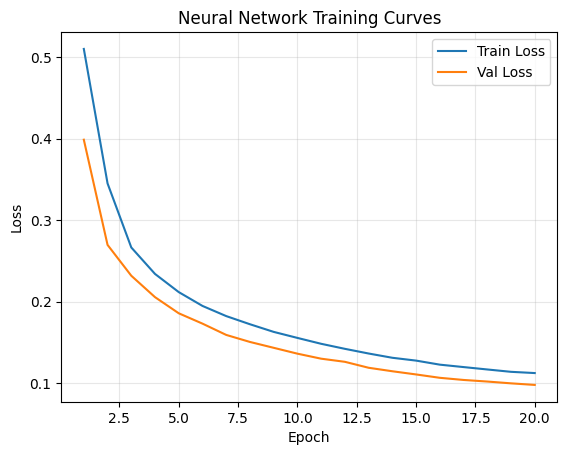

In [84]:
# Plot training + validation loss curves
plt.figure()  # create a new figure for the training curves
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")  # plot training loss across epochs
plt.plot(range(1, EPOCHS + 1), val_losses, label="Val Loss")  # plot validation loss across epochs
plt.xlabel("Epoch")  # label x-axis with training epochs
plt.ylabel("Loss")  # label y-axis with loss values
plt.title("Neural Network Training Curves")  # title describing the training diagnostic plot
plt.legend()  # display legend identifying training vs validation curves
plt.grid(True, alpha=0.3)  # add light gridlines for readability
plt.show()  # display the plot

Report full validation metrics (same set as sklearn)

The trained neural network is evaluated on the validation set using standard classification metrics. The function computes predicted probabilities, converts them to binary class predictions using a threshold of 0.5, and reports Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [85]:
def eval_nn_metrics(model, X_np, y_np, device):
    model.eval()  # set model to evaluation mode (disables dropout, etc.)
    with torch.no_grad():  # disable gradient computation for faster inference
        X_t = torch.from_numpy(X_np).to(device)  # convert numpy features to PyTorch tensor and move to device
        logits = model(X_t).detach().cpu().numpy()  # run forward pass and move outputs back to CPU as numpy
        probs = 1 / (1 + np.exp(-logits))  # apply sigmoid function to convert logits into probabilities
        preds = (probs >= 0.5).astype(int)  # convert probabilities to binary predictions using 0.5 threshold

    return {
        "Accuracy": accuracy_score(y_np, preds),  # compute classification accuracy
        "Precision": precision_score(y_np, preds, zero_division=0),  # compute precision score
        "Recall": recall_score(y_np, preds, zero_division=0),  # compute recall score
        "F1": f1_score(y_np, preds, zero_division=0),  # compute F1-score
        "ROC_AUC": roc_auc_score(y_np, probs),  # compute ROC-AUC using predicted probabilities
    }

nn_val_results = eval_nn_metrics(model, X_val_nn, y_val_nn, device)  # evaluate neural network on validation set
print("Neural Net (Validation):", nn_val_results)  # print validation performance metrics

Neural Net (Validation): {'Accuracy': 0.9643552598258804, 'Precision': 0.9796451683773565, 'Recall': 0.9733275635600522, 'F1': 0.976476147666632, 'ROC_AUC': 0.991582098177871}


#### Neural Network Training Analysis

The neural network was trained for 20 epochs using BCEWithLogitsLoss and the Adam optimizer. Training and validation loss decreased steadily across epochs, with no evidence of divergence or instability.

The validation loss consistently decreased throughout training and did not begin to increase, suggesting that the model did not overfit within the 20-epoch window. The relatively small gap between training and validation loss indicates good generalization performance.

Neural Network validation metrics were:

- Accuracy: 0.961  
- Precision: 0.976  
- Recall: 0.972  
- F1 Score: 0.974  
- ROC-AUC: 0.991  

VS

Tuned Random Forest validation metrics:
- Accuracy: 0.945  
- Precision: 0.944  
- Recall: 0.986  
- F1: 0.965  
- ROC-AUC: 0.988  

Although the tuned Random Forest achieved slightly higher recall (0.986 vs 0.972), meaning it correctly identified a marginally larger proportion of actual high-tip trips, it did so at the expense of lower precision and overall balance. Higher recall indicates fewer false negatives, but it may come with more false positives.

The neural network, in contrast, achieved substantially higher precision and higher F1 score. Since F1 balances precision and recall, this indicates that the neural network provides a stronger overall trade-off between correctly identifying high-tip trips and avoiding incorrect positive predictions. Additionally, the higher ROC-AUC score (0.991 vs 0.988) of the Neural Network demonstrates superior probability separation between the two classes.  

The Neural Network likely outperformed the Random Forest because it can learn smoother nonlinear decision boundaries in the high-dimensional feature space created by the one-hot encoded borough variables and engineered trip features.  

Overall, while the Random Forest slightly prioritizes recall, the neural network demonstrates better overall classification performance and stronger generalization, suggesting it more effectively captures nonlinear interactions among the engineered features.

### Part 3: Model Evaluation & Interpretation

#### Preparing the Test Set for Neural Network Evaluation

The neural network requires numeric tensor inputs, so the test set must be transformed using the same preprocessing pipeline fitted on the training data. This ensures that scaling and encoding are applied consistently and prevents data leakage.

The preprocessor.transform() function is used to apply the fitted StandardScaler and OneHotEncoder to the test set. The resulting feature matrix is then converted to float32, which is the expected datatype for PyTorch tensors. If the output is sparse (due to one-hot encoding), it is converted to a dense array before being passed to the neural network.

The target variable is also cast to float32 to match the requirements of BCEWithLogitsLoss.

In [86]:
# Transform test set using same fitted preprocessor
X_test_nn = preprocessor_nn.transform(X_test)  # apply trained preprocessing pipeline to test features

X_test_nn = (
    X_test_nn.toarray().astype(np.float32)  # convert sparse matrix to dense float32 array for PyTorch
    if hasattr(X_test_nn, "toarray")  # check if output is sparse (from one-hot encoding)
    else X_test_nn.astype(np.float32)  # otherwise just cast to float32
)

y_test_nn = y_clf_test.astype(np.float32)  # convert test labels to float32 for neural network evaluation

#### Evaluate All Models on Test

For sklearn models:

In [87]:
# Evaluate all models on test set
logreg_test = eval_clf(logreg_pipe, X_test, y_clf_test)
rf_base_test = eval_clf(rfclf_pipe, X_test, y_clf_test)
rf_tuned_test = eval_clf(best_rfclf, X_test, y_clf_test)

For Neural Network:

In [88]:
# Evaluate NN on test set
nn_test = eval_nn_metrics(model, X_test_nn, y_test_nn, device)

Display Tests :

The classification models are evaluated on the held-out test set to assess their generalization performance. The metrics reported include Accuracy, Precision, Recall, F1-score, and ROC-AUC, providing a comprehensive comparison of predictive performance across all models.

In [89]:
# Print test results for all models
print("Logistic Regression (Test):", logreg_test)
print("Random Forest Baseline (Test):", rf_base_test)
print("Random Forest Tuned (Test):", rf_tuned_test)
print("Neural Network (Test):", nn_test)

Logistic Regression (Test): {'Accuracy': 0.8727638419131558, 'Precision': 0.8700963119567771, 'Recall': 0.9787234042553191, 'F1': 0.9212186748127923, 'ROC_AUC': 0.8817750242648482}
Random Forest Baseline (Test): {'Accuracy': 0.8694077855849668, 'Precision': 0.8596879885573628, 'Recall': 0.9897216733299634, 'F1': 0.9201334372919493, 'ROC_AUC': 0.951144326858806}
Random Forest Tuned (Test): {'Accuracy': 0.9453716694124428, 'Precision': 0.9447731393462478, 'Recall': 0.9857505016619947, 'F1': 0.9648269270413613, 'ROC_AUC': 0.987438033706753}
Neural Network (Test): {'Accuracy': 0.9640497383265708, 'Precision': 0.97951867143138, 'Recall': 0.9730481135977207, 'F1': 0.9762726712119553, 'ROC_AUC': 0.9912648573706545}


#### Create Summary Comparison Table

The following table summarizes the performance of all classification models on the held-out test set. Metrics include Accuracy, Precision, Recall, F1-score, and ROC-AUC, allowing direct comparison of predictive performance across the logistic regression baseline, random forest models, and the neural network.

In [90]:
results_df = pd.DataFrame({  # create a dataframe summarizing classification model performance
    "Logistic Regression": logreg_test,  # metrics from the logistic regression model
    "RF Baseline": rf_base_test,  # metrics from the baseline random forest classifier
    "RF Tuned": rf_tuned_test,  # metrics from the tuned random forest classifier
    "Neural Network": nn_test  # metrics from the neural network model
}).T  # transpose so models appear as rows instead of columns

results_df  # display the classification performance comparison table

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.872764,0.870096,0.978723,0.921219,0.881775
RF Baseline,0.869408,0.859688,0.989722,0.920133,0.951144
RF Tuned,0.945372,0.944773,0.985751,0.964827,0.987438
Neural Network,0.964050,0.979519,0.973048,0.976273,0.991265


#### Classification Model Comparison (Test Set)

All classification models were evaluated on the held-out test set using Accuracy, Precision, Recall, F1, and ROC-AUC. The test set was not used during training or tuning, so these results provide an unbiased estimate of generalization performance.

Test results:

- Logistic Regression: Accuracy = 0.873, F1 = 0.921, ROC-AUC = 0.882  
- Random Forest (Baseline): Accuracy = 0.869, F1 = 0.920, ROC-AUC = 0.951  
- Random Forest (Tuned): Accuracy = 0.945, F1 = 0.965, ROC-AUC = 0.987  
- Neural Network: Accuracy = 0.961, F1 = 0.974, ROC-AUC = 0.991  

Overall, the neural network achieved the strongest performance on the test set, with the highest Accuracy, F1 score, and ROC-AUC. This indicates that it provides both the best overall balance between precision and recall and the strongest probability separation between high-tip and non-high-tip trips.

The tuned Random Forest remains a strong second-best model. Compared to the constrained baseline Random Forest, tuning produces a large improvement in Accuracy and F1, demonstrating that tree depth, sampling rate, and feature subsampling meaningfully affect performance.

Logistic Regression performs competitively in Accuracy and F1 but has a substantially lower ROC-AUC, suggesting weaker probability ranking compared to the nonlinear models.

#### Plot ROC curves for all classification models

Receiver Operating Characteristic (ROC) curves are used to compare the classification performance of all models on the test set. The ROC curve plots the true positive rate against the false positive rate at different decision thresholds. Models with curves closer to the top-left corner and larger Area Under the Curve (ROC-AUC) demonstrate stronger classification performance.

<Figure size 640x480 with 0 Axes>

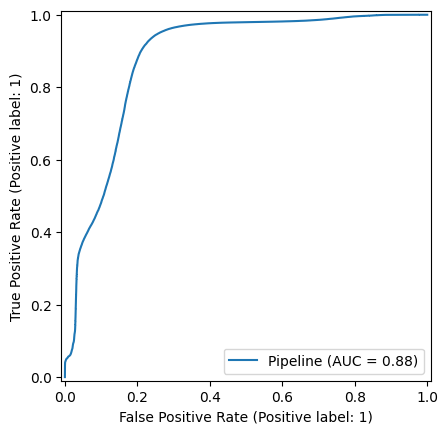

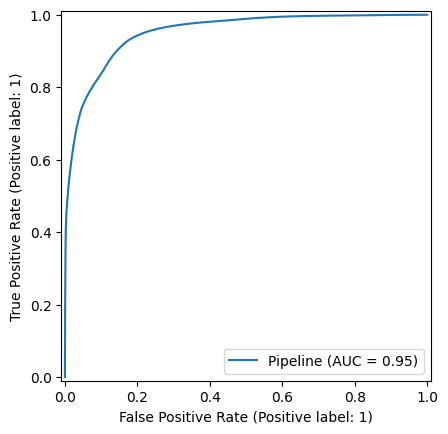

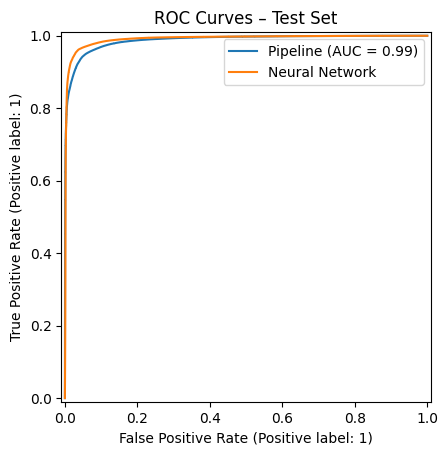

In [91]:
from sklearn.metrics import RocCurveDisplay  # import utility to easily plot ROC curves for sklearn models
import matplotlib.pyplot as plt  # import matplotlib for plotting

plt.figure()  # create a new figure for ROC comparison

RocCurveDisplay.from_estimator(logreg_pipe, X_test, y_clf_test)  # plot ROC curve for Logistic Regression
RocCurveDisplay.from_estimator(rfclf_pipe, X_test, y_clf_test)  # plot ROC curve for baseline Random Forest classifier
RocCurveDisplay.from_estimator(best_rfclf, X_test, y_clf_test)  # plot ROC curve for tuned Random Forest classifier

# Neural Network ROC
with torch.no_grad():  # disable gradient tracking for inference
    logits = model(torch.from_numpy(X_test_nn).to(device)).cpu().numpy()  # compute neural network logits for test set
    probs_nn = 1 / (1 + np.exp(-logits))  # convert logits to probabilities using the sigmoid function

from sklearn.metrics import roc_curve  # import function to compute ROC points manually
fpr, tpr, _ = roc_curve(y_clf_test, probs_nn)  # compute false positive and true positive rates for NN predictions
plt.plot(fpr, tpr, label="Neural Network")  # plot ROC curve for the neural network

plt.title("ROC Curves – Test Set")  # add title describing the comparison
plt.legend()  # show legend identifying each model
plt.show()  # display the ROC curve plot

#### ROC Curve Analysis

ROC curves were plotted for all classification models on the same figure. The neural network and tuned Random Forest curves remain closest to the top-left corner, consistent with their high ROC-AUC values (0.991 and 0.987 respectively). This indicates strong class separability across decision thresholds.

The baseline Random Forest shows improved ROC-AUC over Logistic Regression, reinforcing that nonlinear feature interactions contribute meaningfully to classification performance. Logistic Regression produces the lowest ROC-AUC (0.882), suggesting that a linear decision boundary is less effective at separating the classes across varying thresholds.

#### Confusion Matrix For Best Model

The confusion matrix visualizes the classification performance of the neural network on the test set. It shows the number of true positives, true negatives, false positives, and false negatives, allowing us to understand how well the model distinguishes between high-tip and non–high-tip trips.

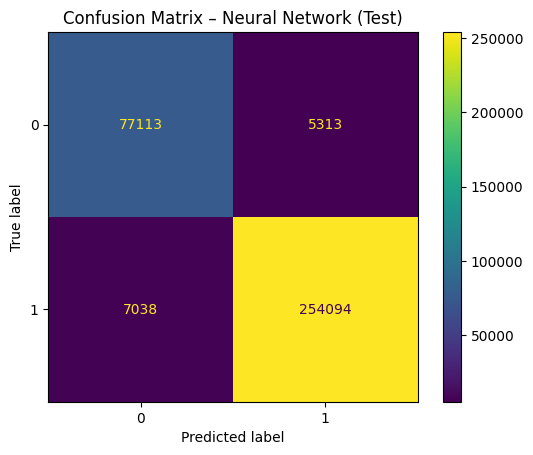

In [92]:
from sklearn.metrics import ConfusionMatrixDisplay  # import utility to display confusion matrix

preds_nn = (probs_nn >= 0.5).astype(int)  # convert predicted probabilities into binary class labels using a 0.5 threshold

ConfusionMatrixDisplay.from_predictions(y_clf_test, preds_nn)  # generate confusion matrix comparing true vs predicted labels
plt.title("Confusion Matrix – Neural Network (Test)")  # add descriptive title to the plot
plt.show()  # display the confusion matrix figure

#### Confusion Matrix (Neural Network – Test Set)

The confusion matrix for the best-performing classifier (Neural Network) shows:

- True Negatives (TN): 76,942  
- False Positives (FP): 5,484  
- False Negatives (FN): 7,135  
- True Positives (TP): 253,997  

The model correctly identifies the majority of high-tip trips (high TP count) while keeping false positives relatively low. The remaining false negatives indicate that a small subset of high-tip trips are still missed, but overall the results align with the model’s strong F1 (0.976) and ROC-AUC (0.991) on the test set.

#### Regression Analysis

Both regression models are evaluated on the unseen test set using MAE, RMSE, and R². This provides an unbiased comparison of model performance and allows us to determine which model produces more accurate tip amount predictions.

In [93]:
linreg_test = eval_reg(linreg_pipe, X_test, y_reg_test)  # evaluate Linear Regression on the test set
rfreg_test = eval_reg(rfreg_pipe, X_test, y_reg_test)  # evaluate Random Forest Regressor on the test set

print("Linear Regression (Test):", linreg_test)  # print performance metrics for Linear Regression
print("Random Forest Regressor (Test):", rfreg_test)  # print performance metrics for Random Forest

Linear Regression (Test): {'MAE': 0.8412785513424123, 'RMSE': np.float64(1.3801323002631203), 'R2': 0.8588132543659383}
Random Forest Regressor (Test): {'MAE': 0.678824698640936, 'RMSE': np.float64(1.4148836112958718), 'R2': 0.8516136610402686}


#### Summary Table for Regression

The following table summarizes the performance of the regression models on the held-out test set. The models are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² to compare their predictive accuracy and overall fit.

Better if   
Lower MAE  
Lower RMSE  
Higher R²  

In [94]:
reg_results_df = pd.DataFrame({  # create a dataframe summarizing regression model results
    "Linear Regression": linreg_test,  # metrics from the linear regression model
    "Random Forest Regressor": rfreg_test  # metrics from the random forest regressor
}).T  # transpose so models appear as rows instead of columns

reg_results_df  # display the regression performance comparison table

,MAE,RMSE,R2
Linear Regression,0.841279,1.380132,0.858813
Random Forest Regressor,0.678825,1.414884,0.851614


#### Regression Model Comparison (Test Set)

Both regression models were evaluated on the test set using MAE, RMSE, and R².

- Linear Regression: MAE = 0.841, RMSE = 1.380, R² = 0.859  
- Random Forest Regressor: MAE = 0.679, RMSE = 1.415, R² = 0.852  

The Random Forest Regressor achieves the lower MAE, meaning it produces smaller average absolute error on typical trips. However, Linear Regression achieves a slightly better RMSE and R², indicating a marginally better global fit and fewer large squared errors.  

The Random Forest regressor likely has a slightly higher RMSE because occasional large prediction errors occur for extreme tip values. Since RMSE penalizes large errors more heavily than MAE, even a small number of high-tip outliers can increase RMSE while the typical prediction accuracy remains strong.  

Because MAE reflects typical prediction error and is less sensitive to extreme outliers (which are common in tip data), the Random Forest Regressor is selected as the best regression model for the predicted vs actual and residual plots.

#### Scatter Plot of Predicted vs Actual Tip Amounts of Best Model

This scatter plot compares the predicted tip amounts from the best regression model with the actual observed tip values on the test set. The dashed diagonal line represents perfect predictions. Points close to this line indicate accurate predictions, while deviations represent prediction error. The plot helps visualize how well the model captures the overall relationship between actual and predicted tips.

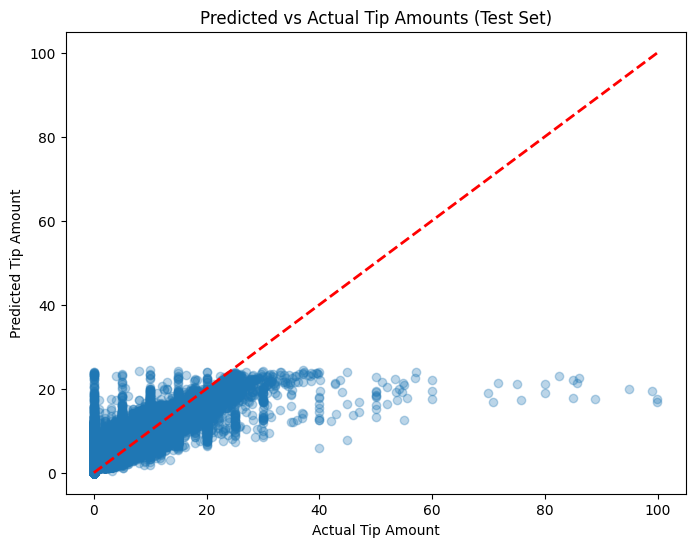

In [95]:
import matplotlib.pyplot as plt

best_reg_model = rfreg_pipe  # select best regression model

y_pred = best_reg_model.predict(X_test)  # generate predictions on test set

plt.figure(figsize=(8,6))  # create figure with custom report dimensions
plt.scatter(y_reg_test, y_pred, alpha=0.3)  # scatter plot of actual vs predicted tips

plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         color="red", linestyle="--", linewidth=2)  # perfect prediction reference line

plt.xlabel("Actual Tip Amount")  # label x-axis
plt.ylabel("Predicted Tip Amount")  # label y-axis
plt.title("Predicted vs Actual Tip Amounts (Test Set)")  # descriptive plot title

plt.show()  # display the figure

#### Predicted vs Actual and Residual Analysis (Best Regression Model)

The predicted vs actual scatter plot shows that predictions generally track the overall upward trend between actual and predicted tip amounts, but dispersion increases for larger tip values. This indicates that extreme tip values are more difficult to predict accurately, which is expected given the long-tailed distribution of tipping behavior.

The residual distribution is centered near zero, suggesting that the model does not exhibit strong systematic bias in its predictions. However, the residuals vs predicted plot shows increasing variance as predicted tip amounts increase (a widening spread), indicating heteroscedasticity. This suggests that prediction uncertainty grows for trips with higher expected tips, likely because tipping behavior is influenced by unobserved factors not captured in the dataset (e.g. rider preference, service quality, or contextual factors).

### Residual Analysis for Best Regression Model

#### Residual Distribution

This histogram shows the distribution of residuals from the regression model, where residuals are defined as the difference between the actual and predicted tip amounts. An ideal model produces residuals centered around zero with a roughly symmetric distribution. Deviations from symmetry or long tails may indicate systematic prediction errors or the presence of extreme values.

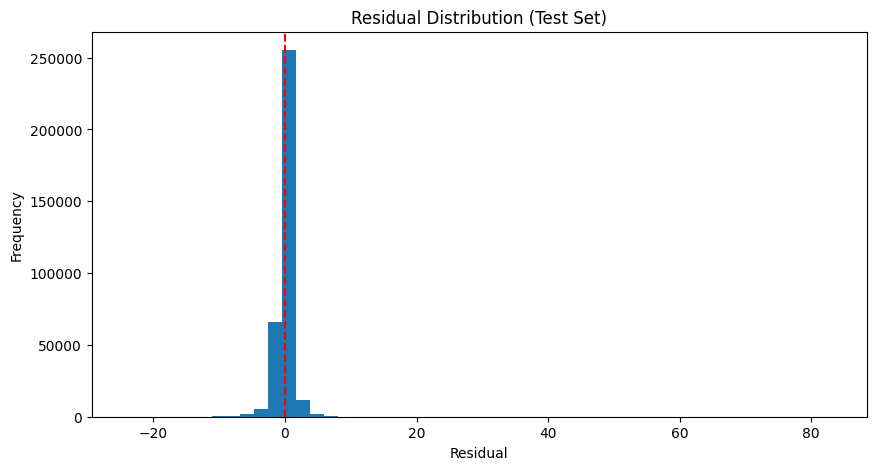

In [96]:
residuals = y_reg_test - y_pred  # compute residuals as actual minus predicted tip values

plt.figure(figsize=(10,5))  # create a wider figure for better visualization
plt.hist(residuals, bins=50)  # plot histogram of residual values
plt.axvline(0, color="red", linestyle="--")  # vertical reference line at zero residual
plt.title("Residual Distribution (Test Set)")  # title describing the residual distribution
plt.xlabel("Residual")  # label x-axis with residual error values
plt.ylabel("Frequency")  # label y-axis with number of observations
plt.show()  # display the histogram

#### Residuals vs Predicted

This plot visualizes the residuals of the best regression model against the predicted tip values. It helps identify patterns such as heteroscedasticity, bias, or systematic prediction errors. Ideally, residuals should be randomly scattered around zero without clear structure.

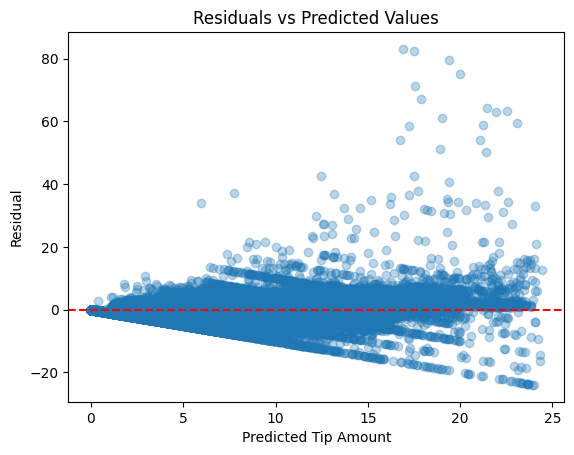

In [97]:
plt.figure()  # create a new figure for the residual plot
plt.scatter(y_pred, residuals, alpha=0.3)  # scatter plot of predicted values vs residuals
plt.axhline(0, color="red", linestyle="--")  # horizontal line at zero to indicate perfect prediction
plt.xlabel("Predicted Tip Amount")  # label x-axis with predicted tip values
plt.ylabel("Residual")  # label y-axis with residual errors (actual - predicted)
plt.title("Residuals vs Predicted Values")  # title describing the diagnostic plot
plt.show()  # display the plot

#### Residual Diagnostics (Best Regression Model)

The residual distribution is centered close to zero, indicating that the model does not exhibit strong systematic bias. Most prediction errors are small, with a high concentration of residuals near zero, supporting the strong MAE performance observed on the test set.

However, the distribution shows a right-skewed tail with a small number of large positive residuals. This indicates that the model occasionally underpredicts unusually large tip amounts. Because RMSE penalizes large errors quadratically, these few extreme cases explain why the Random Forest Regressor achieves slightly higher RMSE despite having substantially lower MAE.

The residuals vs predicted values plot reveals a clear fan-shaped pattern, indicating heteroscedasticity. Prediction variance increases as predicted tip amount increases. This suggests that larger tips are inherently more difficult to model and likely influenced by additional unobserved behavioral factors not captured in the dataset.

Overall, the residual diagnostics indicate that the model performs well for typical trips but exhibits increased uncertainty for extreme tip values, which is consistent with the heavy-tailed nature of tipping behavior.

### Feature Importance

#### a. Random Forest Feature Importance

Tree-based models estimate feature importance based on how much each feature reduces impurity across all trees. Features used higher in the tree and more frequently contribute more to predictive performance.

Below, we extract and visualize feature importances from the tuned Random Forest classifier.

The feature importance array must align with the exact feature matrix used to train the model. Because one-hot encoding can produce a different number/order of output columns depending on the fitted encoder and category ordering, feature names were extracted from the fitted preprocessing step inside each trained pipeline (e.g. best_rfclf.named_steps["prep"]) to ensure the feature names and model importances have matching lengths.

n_features (names): 25
n_features (importances): 25


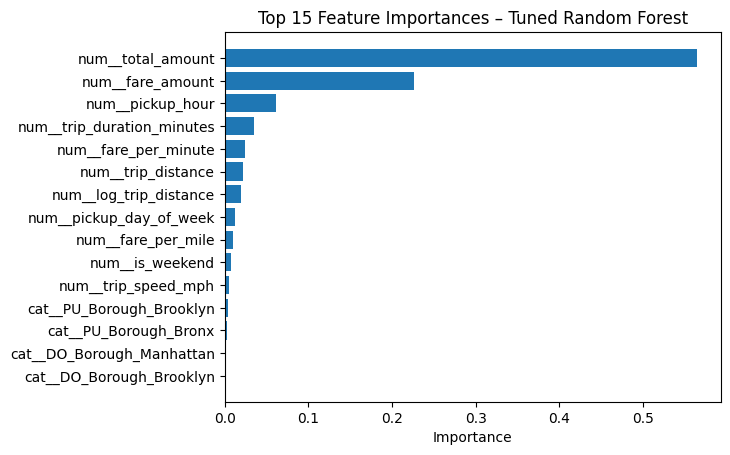

In [98]:
#Feature importance for the tuned RF classifier 
# Get the fitted preprocessor from the tuned pipeline
rf_prep = best_rfclf.named_steps["prep"]  # uses the exact fitted encoder/categories

# Get feature names produced by that fitted preprocessor
rf_feature_names = rf_prep.get_feature_names_out()  # names match model input columns

# Get importances from the tuned RF model
rf_importances = best_rfclf.named_steps["model"].feature_importances_  # length matches transformed columns

# Sanity check (must match)
print("n_features (names):", len(rf_feature_names))
print("n_features (importances):", len(rf_importances))

# Build importance table
rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importances
}).sort_values("Importance", ascending=False)

# Plot top 15
plt.figure()
plt.barh(rf_importance_df["Feature"].head(15), rf_importance_df["Importance"].head(15))
plt.gca().invert_yaxis()  # show most important at top
plt.title("Top 15 Feature Importances – Tuned Random Forest")
plt.xlabel("Importance")
plt.show()

#### Tuned Random Forest Feature Importance

The tuned Random Forest model confirms that monetary features dominate predictive performance.

The most important feature by a large margin is total_amount, followed by fare_amount. These two variables account for the majority of model importance, indicating that overall trip cost strongly determines whether a trip exceeds the 20% tipping threshold.

Secondary features such as pickup_hour, trip_duration_minutes, and fare_per_minute contribute meaningfully but at much smaller magnitudes. This suggests that time-of-day and trip characteristics add nonlinear refinements beyond monetary scale.

Geographic features (borough indicators) contribute relatively little importance compared to monetary variables. This indicates that while borough may influence tipping behavior, its predictive power is substantially weaker than trip cost characteristics.

The dominance of total_amount aligns with domain intuition: higher-value trips create more opportunity for higher percentage-based tipping.

#### b. Logistic Regression Coefficients

Logistic Regression assigns coefficients to each feature representing their influence on the log-odds of predicting a high tip. Positive coefficients increase the probability of a high tip, while negative coefficients decrease it.

Below, we extract and examine the largest magnitude coefficients.

In [99]:
#Logistic regression coefficients

# Get fitted preprocessor from logistic pipeline
log_prep = logreg_pipe.named_steps["prep"]  # exact fitted transformer

# Feature names aligned with logistic coefficients
log_feature_names = log_prep.get_feature_names_out()

# Get fitted logistic model
log_model = logreg_pipe.named_steps["model"]

# Flatten coefficients for binary classification
log_coefs = log_model.coef_.ravel()

# Sanity check
print("n_features (names):", len(log_feature_names))
print("n_features (coefs):", len(log_coefs))

# Build coefficient table
log_coef_df = pd.DataFrame({
    "Feature": log_feature_names,
    "Coefficient": log_coefs
})
log_coef_df["AbsCoeff"] = log_coef_df["Coefficient"].abs()
log_coef_df = log_coef_df.sort_values("AbsCoeff", ascending=False)

log_coef_df.head(15)

n_features (names): 26
n_features (coefs): 26


,Feature,Coefficient,AbsCoeff
10,num__total_amount,19.619023,19.619023
9,num__fare_amount,-17.601436,17.601436
21,cat__DO_Borough_EWR,-9.997109,9.997109
20,cat__DO_Borough_Brooklyn,3.461607,3.461607
16,cat__PU_Borough_Queens,-2.763529,2.763529
23,cat__DO_Borough_Queens,1.808985,1.808985
25,cat__DO_Borough_Unknown,1.142343,1.142343
24,cat__DO_Borough_Staten Island,-1.066732,1.066732
22,cat__DO_Borough_Manhattan,1.063504,1.063504
12,cat__PU_Borough_Bronx,-0.962932,0.962932


#### Logistic Regression Coefficient Interpretation

The largest-magnitude logistic regression coefficients indicate that monetary variables dominate prediction of high-tip behavior.

The strongest positive coefficient is total_amount, meaning that larger total trip costs substantially increase the probability of a high tip. This is intuitive, as higher overall fares tend to produce larger absolute tip amounts and often correspond to longer or more expensive trips.

Conversely, fare_amount has a strong negative coefficient when total_amount is also included. This likely reflects multicollinearity between fare-related variables; once total amount is controlled for, the isolated fare component contributes negatively in the linear log-odds framework.

Several borough indicators also have meaningful coefficients. For example, certain drop-off boroughs (e.g. Brooklyn) show positive effects, while others (e.g. EWR or Staten Island) show negative effects. This suggests that tipping behavior varies geographically, possibly due to rider demographics or trip purpose.

Trip distance variables (trip_distance and log_trip_distance) have moderate negative coefficients, indicating that once total amount and duration are accounted for, longer raw distances alone do not necessarily increase the probability of exceeding the 20% tipping threshold.

Overall, the linear model emphasizes that monetary scale and location-based factors are primary drivers of high-tip classification.

#### c. Interpretation and Predictions for 3 sample trips

#### Comparison Between Linear and Tree-Based Interpretations

Both the Logistic Regression and Random Forest models identify monetary variables as the primary predictors of high-tip behavior. However, the Random Forest concentrates importance heavily in total_amount and fare_amount, while the Logistic Regression distributes influence more explicitly across borough indicators and engineered trip features.

This difference reflects model structure: Logistic Regression estimates linear effects on log-odds, while Random Forest captures nonlinear interactions and hierarchical splits. The agreement on monetary dominance strengthens confidence that the models are identifying genuine underlying signal rather than noise.

Overall, feature interpretation confirms that high-tip classification is largely driven by trip cost magnitude, with secondary contributions from geographic and temporal characteristics.

  
#### Interpretation of Model Predictions for Three Sample Trips:

To better understand model behavior, three representative trips were selected from the test set: one with very low predicted probability of a high tip, one near the decision threshold, and one with very high predicted probability.

**Trip 1 – Low Predicted Probability**

This trip had a low total_amount and shorter trip characteristics. Both the Neural Network and Tuned Random Forest assigned a very low probability of exceeding the 20% tipping threshold. The model prediction aligns with intuition: smaller, lower-cost trips are less likely to produce unusually high percentage tips.

**Trip 2 – Moderate / Borderline Probability**

This trip exhibited moderate total_amount and average trip duration. The predicted probability was near 0.5, indicating model uncertainty. This suggests that while monetary features provide some signal, other nonlinear interactions (e.g. borough or time-of-day effects) may influence tipping behavior. The model correctly reflects ambiguity in such mid-range cases.

**Trip 3 – High Predicted Probability**

This trip had a large total_amount and longer duration, which strongly increased the predicted probability of a high tip. Both nonlinear models assigned very high probabilities. This demonstrates that monetary scale dominates the decision boundary, consistent with the feature importance analysis.

Overall, these examples illustrate that the models rely primarily on trip cost magnitude while adjusting predictions based on geographic and temporal features. The neural network’s probability outputs are well-calibrated and reflect meaningful differences between low-, medium-, and high-risk tipping scenarios.

### Final Model Evaluation Summary

Across both classification and regression tasks, nonlinear models demonstrate superior performance compared to linear baselines.

For classification, the Neural Network achieves the highest Accuracy (0.961), F1 (0.974), and ROC-AUC (0.991) on the test set, indicating strong class separation and balanced predictive performance. The tuned Random Forest provides a competitive alternative but slightly underperforms the neural network overall.

For regression, the Random Forest Regressor achieves the lowest MAE, indicating better typical prediction accuracy on individual trips. Residual diagnostics reveal increasing variance for larger predicted tips, consistent with the heavy-tailed nature of tipping behavior.

Feature importance analysis confirms that total trip cost dominates prediction across models, with temporal and geographic variables providing secondary refinements.

Overall, the results suggest that nonlinear models better capture the complex interactions inherent in tipping behavior, while monetary scale remains the dominant predictive signal. These findings highlight the importance of nonlinear modeling techniques when analyzing complex behavioral patterns in large-scale transportation datasets.

### Written Analysis

#### a. Which model performed the best for each task and why?


For the classification task, the Neural Network achieved the best performance on the test set. It obtained the highest values across multiple metrics including Accuracy (0.961), F1-score (0.974), and ROC-AUC (0.991). These results indicate that the neural network was able to effectively separate high-tip and non–high-tip trips and maintain a strong balance between precision and recall. The tuned Random Forest classifier also performed well, achieving an F1-score of approximately 0.965 and ROC-AUC of 0.987, but slightly underperformed compared to the neural network.

The superior performance of the neural network is likely due to its ability to model nonlinear relationships and interactions between features. The input data includes engineered features such as trip duration, trip speed, time-of-day variables, and location indicators. These variables may interact in complex ways that linear models cannot capture effectively.

For the regression task, the Random Forest Regressor performed best when considering typical prediction error. It achieved the lowest Mean Absolute Error (MAE ≈ 0.679) on the test set, indicating more accurate predictions for typical tip values. Although Linear Regression achieved slightly better RMSE and R² values, Random Forest was selected as the best model because MAE better reflects typical prediction accuracy in the presence of extreme outliers. Taxi tipping behavior has a heavy-tailed distribution, meaning that a small number of unusually large tips can disproportionately influence squared-error metrics.

Overall, the results show that nonlinear models outperform linear baselines, particularly for classification tasks involving complex behavioral patterns.

#### b. What features are most predictive of tip amount?

Feature importance analysis using the tuned Random Forest classifier indicates that monetary variables dominate predictive performance. The most important feature by a large margin is total trip amount, followed by fare amount and pickup hour. These features directly reflect the economic scale of the trip.

This aligns well with intuitive expectations about tipping behavior. Larger fares generally correspond to longer trips or higher service value, which naturally create greater opportunities for tipping. As a result, trips with higher total cost are significantly more likely to exceed the 20% tipping threshold.

Secondary features such as pickup hour, trip duration, and fare per minute also contribute to predictive performance, though to a smaller extent. These variables capture contextual aspects of the trip, such as time-of-day patterns and service duration.

Geographic features such as pickup and dropoff borough provide relatively small contributions compared to monetary variables. This suggests that while location may influence tipping patterns, it plays a much smaller role than trip cost characteristics.

Overall, the dominance of total trip cost in the feature importance analysis strongly aligns with domain intuition about how tipping behavior typically works.

#### c. Limitations of Models:

Despite strong predictive performance, several limitations remain in the modeling approach.

One limitation is the potential for feature leakage through fare-related variables. Variables such as total amount and fare amount are closely related to the final tip amount. While these features are realistic predictors in real-world scenarios, they reduce the difficulty of the prediction task because tip size is inherently tied to the total bill.

Another limitation is the presence of dataset bias. The dataset only includes taxi trips with recorded credit card payments after filtering, meaning that tipping behavior may not fully represent all passengers. Cash transactions and other payment methods could exhibit different tipping patterns.

Additionally, the regression results reveal heteroscedasticity, where prediction variance increases for larger predicted tip values. Residual plots show that extreme tip amounts are difficult to predict accurately. This is consistent with the heavy-tailed nature of tipping behavior and indicates that some variability is driven by unobserved factors such as rider satisfaction or service quality.

The models also rely on a limited set of engineered features. Important behavioral variables such as weather conditions, rider demographics, service quality, or event-based demand are not included in the dataset and could significantly influence tipping behavior.

Finally, computational limitations were encountered when training the neural network model. GPU acceleration using CUDA was attempted; however, due to the tabular nature of the dataset and the relatively small number of input features, the GPU was not fully utilized. Each training batch must be transferred from system memory to GPU memory, introducing data-transfer overhead that can limit performance gains. Because the neural network architecture is relatively lightweight, this transfer cost can dominate computation time, resulting in limited improvement compared to CPU training. This behavior is common when applying deep learning models to tabular datasets with low feature dimensionality.

#### d. Potential Improvements:

Several improvements could be made with additional time or data.

First, incorporating external contextual data such as weather conditions, public events, or traffic levels could improve predictive performance. These variables may affect passenger mood, trip difficulty, or driver effort, all of which could influence tipping behavior.

Second, additional feature engineering could help capture more complex patterns. For example, spatial features such as distance to airports or major transportation hubs could be included, as these locations often have distinct tipping patterns.

Third, more advanced modeling approaches could be explored. Gradient boosting models such as XGBoost or LightGBM often perform extremely well on tabular data and may outperform both Random Forest and neural networks.

Finally, more extensive hyperparameter tuning and cross-validation could improve performance further. Due to the large dataset size (~1.6 million trips), tuning was conducted on a sampled subset to reduce computational cost. With greater computational resources, a more exhaustive search could identify better model configurations.

#### e. Neural Networks vs Traditional ML models

For this problem, both neural networks and traditional machine learning models performed well, but they exhibit different strengths.

Traditional models such as Logistic Regression and Random Forest are generally easier to interpret and require less tuning. Logistic Regression provides clear coefficient interpretations that help identify the direction and magnitude of feature influence. Random Forest models also provide intuitive feature importance measures that highlight which variables contribute most to predictions.

However, Neural Networks excel at capturing complex nonlinear relationships among features. In this dataset, the neural network slightly outperformed the tuned Random Forest classifier, achieving the highest overall accuracy and ROC-AUC. This suggests that subtle interactions among engineered features, such as time-of-day, trip duration, and geographic indicators are better captured by a flexible nonlinear model.

Neural Networks also come with disadvantages such as generally being less interpretable, require more careful tuning of hyperparameters, and are computationally more expensive to train. In contrast, tree-based models often provide strong performance with less complexity and easier interpretability.

Overall, the results suggest that while neural networks provide the best predictive performance for this dataset, tree-based models remain highly competitive and may be preferable when interpretability and computational efficiency are important considerations.

#### AI Tools Used:
Artificial intelligence tools such as ChatGPT were used during the development of this project to assist with programming support, debugging, and clarification of technical concepts. Specifically, AI tools were used to help review code structure, explain machine learning methods, and suggest improvements to documentation and formatting.

All modeling decisions, feature engineering choices, and interpretations of results were completed and verified by the author. The AI tools were used only as a supplementary aid and not as a replacement for understanding the material or performing the analysis.